# 1.3 Processing Times
**Responsible:** _Thomas P. Hartel_

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pm4py
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

sns.set(style="whitegrid")

In [2]:
LOG1_PATH = "../data/BPI Challenge 2017.xes"
LOG2_PATH = "../data/generated_log.xes"

CASE_COL = "case:concept:name"
ACTIVITY_COL = "concept:name"
TIME_COL = "time:timestamp"

In [3]:
def load_log(path):
    df = pm4py.read_xes(path, variant="r4pm")

    df[TIME_COL] = pd.to_datetime(df[TIME_COL])

    df = df.sort_values([CASE_COL, TIME_COL])

    return df

log1 = load_log(LOG1_PATH)
log2 = load_log(LOG2_PATH)

In [4]:
def format_data(log: pd.DataFrame):
            log = log.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)
            
            cases = log["case:concept:name"].values
            activities = log["concept:name"].values
            transitions = log["lifecycle:transition"].values
            resources = log["org:resource"].values
            app_types = log["case:ApplicationType"].values
            req_amounts = log["case:RequestedAmount"].values
            timestamps = log["time:timestamp"].values
            
            ts_seconds = log["time:timestamp"].astype('int64').values // 10**9
            hours = log["time:timestamp"].dt.hour.values
            weekdays = log["time:timestamp"].dt.weekday.values

            event_times = []
            
            last_complete_time = {}
            active_starts = {}
            total_active_times = {}
            first_hours = {}
            first_weekdays = {}
            rework_counts = {}
            
            case_app_types = {}
            case_req_amounts = {}
            waiting_time={}

            for i in range(len(log)):
                case = cases[i]
                activity = activities[i]
                t_sec = ts_seconds[i]
                transition = transitions[i]
                group = (case, activity)

                if pd.notna(app_types[i]):
                    case_app_types[case] = app_types[i]
                if pd.notna(req_amounts[i]):
                    case_req_amounts[case] = req_amounts[i]

                if group not in total_active_times:
                    total_active_times[group] = 0.0
                if group not in rework_counts:
                    rework_counts[group] = 0
                
                if transition == "start":
                    active_starts[group] = t_sec
                    total_active_times[group] = 0.0
                    first_hours[group] = hours[i]
                    first_weekdays[group] = weekdays[i]
                    rework_counts[group] += 1

                    waiting_time[case] = float(t_sec - last_complete_time[case]) if case in last_complete_time else 0.0
                    
                elif transition == "resume":
                    active_starts[group] = t_sec
                    
                elif transition == "suspend":
                    if active_starts.get(group) is not None:
                        total_active_times[group] += (t_sec - active_starts[group])
                        active_starts[group] = None
                    
                elif transition == "complete":
                    if active_starts.get(group) is not None:
                        total_active_times[group] += (t_sec - active_starts[group])
                        active_starts[group] = None

                    infos = {
                        "case:concept:name": case,
                        "concept:name": activity,
                        "processing_time": float(total_active_times[group]),
                        "waiting_time": waiting_time.get(case,0),
                        "org:resource": resources[i],
                        "case:RequestedAmount": case_req_amounts.get(case, np.nan),
                        "case:ApplicationType": case_app_types.get(case, "Unknown"),
                        "hour_of_day": first_hours.get(group, hours[i]),
                        "weekday": first_weekdays.get(group, weekdays[i]),
                        "rework_count": rework_counts[group],
                        "final_timepoint": timestamps[i]
                    }
                    
                    if True and "strain_time_difference" in log.columns:
                        infos["strain_time"] = log["strain_time_difference"].values[i]
                        
                    event_times.append(infos)
                    
                    total_active_times[group] = 0.0
                    last_complete_time[case] = t_sec

            return pd.DataFrame.from_records(event_times)

In [5]:
df1 = format_data(log1)
df2 = format_data(log2)

In [ ]:
df = df1

df = df.dropna(subset=['concept:name', 'org:resource', 'processing_time'])
df = df[df['processing_time'] >= 0]

df['log_processing_time'] = np.log1p(df['processing_time'])

X_act = df[['concept:name']]
X_res = df[['org:resource']]
X_both = df[['concept:name', 'org:resource']]
y = df['log_processing_time']

def evaluate_feature_relevance(X, y, feature_name):
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = encoder.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    print(f"Variance in Processing Time explained by [{feature_name}] (R² Score): {r2:.4f}")
    return r2

r2_activity = evaluate_feature_relevance(X_act, y, "Activity (concept:name)")
r2_resource = evaluate_feature_relevance(X_res, y, "Resource (org:resource)")
r2_combined = evaluate_feature_relevance(X_both, y, "Combined (Activity + Resource)")

encoder_tree = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_both_encoded = encoder_tree.fit_transform(X_both)
feature_names = encoder_tree.get_feature_names_out(['concept:name', 'org:resource'])

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_both_encoded, y)

importances = rf.feature_importances_
act_importance = sum(importances[i] for i, name in enumerate(feature_names) if "concept:name" in name)
res_importance = sum(importances[i] for i, name in enumerate(feature_names) if "org:resource" in name)

print(f"Total Importance of Activity: {act_importance:.4f}")
print(f"Total Importance of Resource: {res_importance:.4f}")

Variance in Processing Time explained by [Activity (concept:name)] (R² Score): 0.5255
Variance in Processing Time explained by [Resource (org:resource)] (R² Score): 0.0736
Variance in Processing Time explained by [Combined (Activity + Resource)] (R² Score): 0.5372

--- Running Tree-Based Feature Importance ---
Total Importance of Activity: 0.9084
Total Importance of Resource: 0.0916


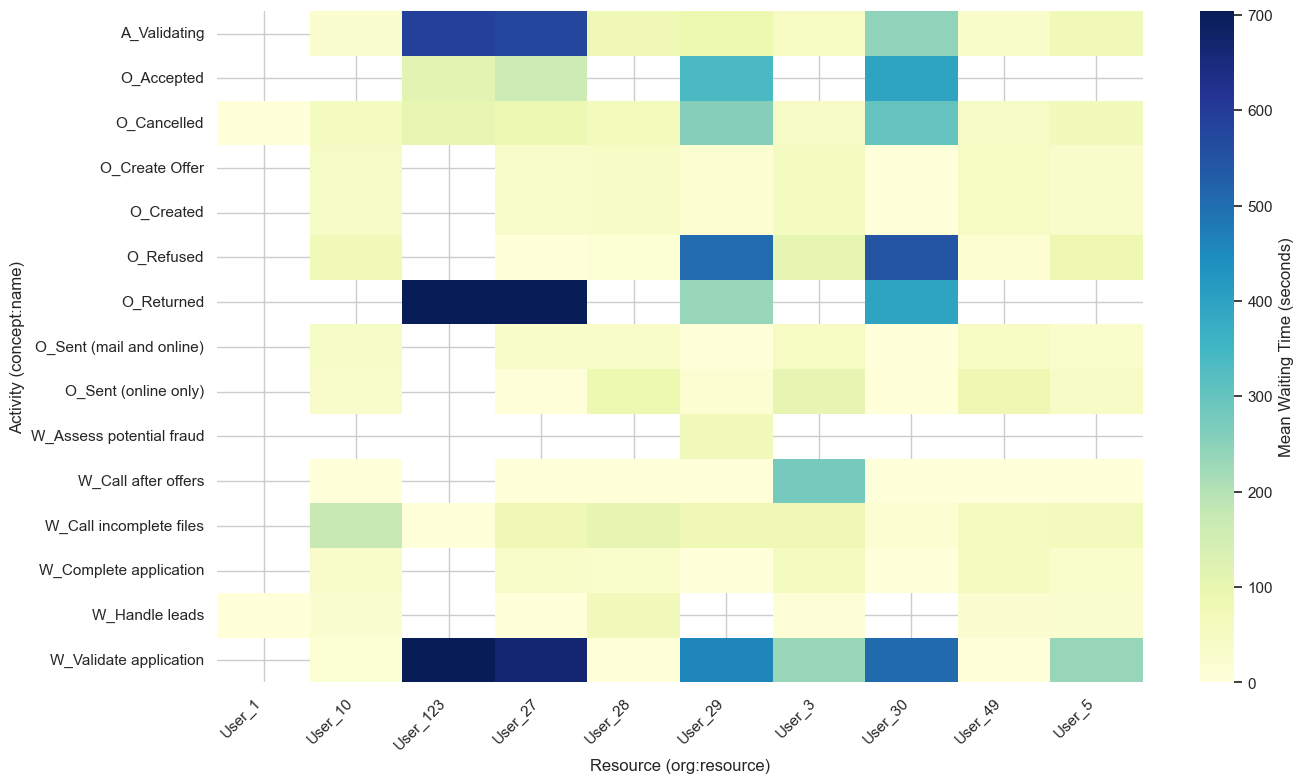

In [22]:
df = df1

unique_activities = sorted(df['concept:name'].unique())
last_15_alphabetical_activities = unique_activities[-15:]

top_resources = df['org:resource'].value_counts().nlargest(10).index

df_filtered = df[
    df['concept:name'].isin(last_15_alphabetical_activities) & 
    df['org:resource'].isin(top_resources)
]

pivot_table = df_filtered.pivot_table(
    index='concept:name', 
    columns='org:resource', 
    values='waiting_time', 
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_table, 
    cmap='YlGnBu',
    robust=True,
    annot=False,
    cbar_kws={'label': 'Mean Waiting Time (seconds)'}
)

plt.xlabel('Resource (org:resource)', fontsize=12)
plt.ylabel('Activity (concept:name)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [35]:
summary = pd.DataFrame({
    "Log 1": {
        "Mean Processing": df1["processing_time"].mean(),
        "Median Processing": df1["processing_time"].median(),
        "Mean Waiting": df1["waiting_time"].mean(),
        "Median Waiting": df1["waiting_time"].median(),
    },
    "Log 2": {
        "Mean Processing": df2["processing_time"].mean(),
        "Median Processing": df2["processing_time"].median(),
        "Mean Waiting": df2["waiting_time"].mean(),
        "Median Waiting": df2["waiting_time"].median(),
    }
})

print(summary)

                        Log 1     Log 2
Mean Processing      0.086933  0.001830
Median Processing    0.000000  0.000000
Mean Waiting       150.719776  0.241353
Median Waiting       0.000000  0.000000


In [36]:
comparison = (
    df1.groupby("concept:name")
       .agg(
           processing_log1=("processing_time", "mean"),
           waiting_log1=("waiting_time", "mean")
       )
       .merge(
           df2.groupby("concept:name")
              .agg(
                  processing_log2=("processing_time", "mean"),
                  waiting_log2=("waiting_time", "mean")
              ),
           left_index=True,
           right_index=True,
           how="outer"
       )
)

comparison["Processing Difference"] = (
    comparison["processing_log2"] - comparison["processing_log1"]
)

comparison["Waiting Difference"] = (
    comparison["waiting_log2"] - comparison["waiting_log1"]
)

comparison

,processing_log1,waiting_log1,processing_log2,waiting_log2,Processing Difference,Waiting Difference
concept:name,,,,,,
A_Accepted,0.000000,50.484528,0.000000,2.506221,0.000000,-47.978308
A_Cancelled,0.000000,13.900105,0.000713,0.004277,0.000713,-13.895829
A_Complete,0.000000,0.000000,0.001372,0.086650,0.001372,0.086650
A_Concept,0.000000,0.038592,0.000429,0.046332,0.000429,0.007740
A_Create Application,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A_Denied,0.000000,529.078870,0.000000,0.318777,0.000000,-528.760093
A_Incomplete,0.000000,79.886098,0.002212,0.371681,0.002212,-79.514417
A_Pending,0.000000,298.011145,0.000000,0.427350,0.000000,-297.583794
A_Submitted,0.000000,0.000000,0.000000,0.189189,0.000000,0.189189


In [ ]:
groups1 = {k: g for k, g in df1.groupby(["concept:name"])}
groups2 = {k: g for k, g in df2.groupby(["concept:name"])}

keys = sorted(set(groups1.keys()).union(groups2.keys()))

for activity in keys:

    g1 = groups1.get((activity), pd.DataFrame())
    g2 = groups2.get((activity), pd.DataFrame())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{activity}", fontsize=14)

    plotted = False

    for ax, metric, title in zip(axes,
        ["processing_time", "waiting_time"],
        ["Processing Time", "Waiting Time"],):

        x1 = g1.get(metric, pd.Series(dtype=float)).dropna()
        x2 = g2.get(metric, pd.Series(dtype=float)).dropna()

        if len(x1) == 0 or np.all(x1 == 0):
            ax.set_visible(False)
            continue

        if len(x2) == 0:
            x2 = pd.Series([0.0])

        if x1.nunique() > 1:
            sns.kdeplot(
                x=x1,
                ax=ax,
                fill=True,
                alpha=0.35,
                linewidth=2,
                label="Log 1",
            )
        else:
            ax.axvline(
                x1.iloc[0],
                color="C0",
                linewidth=2,
                linestyle="--",
                label="Log 1",
            )

        if x2.nunique() > 1:
            sns.kdeplot(
                x=x2,
                ax=ax,
                fill=True,
                alpha=0.35,
                linewidth=2,
                label="Log 2",
            )
        else:
            ax.axvline(
                x2.iloc[0],
                color="C1",
                linewidth=2,
                linestyle="--",
                label="Log 2",
            )

        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Density")
        ax.legend()

        plotted = True

    if plotted:
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)